# 📊 Marketing Campaign Analysis — SQL Project

---

## 👤 Project Info

| | |
|---|---|
| Dataset | market.csv |
| Tool | Jupyter Notebook + SQLite |
| Language | Python + SQL |
| Table Name | campaigns |
| Total Rows | 10,000 |

---

## 🔑 Phase 1 — Setup & Database Load

### Steps Performed
| # | Step | Action |
|---|---|---|
| 1 | Import Libraries | pandas, sqlite3 |
| 2 | Load CSV | pd.read_csv() |
| 3 | Check Nulls | isnull().sum() |
| 4 | Remove Nulls | dropna() |
| 5 | Check Duplicates | duplicated().sum() |
| 6 | Fix Negative Values | Ad_Spend, Time_on_Site_Minutes |
| 7 | Load into SQLite | df.to_sql() |
| 8 | Verify | SELECT COUNT(*) |

### Issues Found & Fixed
| Column | Issue | Fix |
|---|---|---|
| Age | 2 null values | Dropped rows |
| Income | 2 null values | Dropped rows |
| Ad_Spend | 1 negative value | Removed rows |
| Time_on_Site_Minutes | 68 negative values | Removed rows |

### Final Clean Data
- Original Rows → 10,000
- After Cleaning → ~9,927
   rows
- Database → marketing.db
- Table Name → campaigns

---

In [1]:
import pandas as pd
import sqlite3

In [2]:
file_path = "dataset.csv"
df = pd.read_csv(file_path)

In [3]:
df.head()

,Customer_ID,Age,Income,Gender,Region,Marketing_Channel,Campaign_Type,Device_Type,Ad_Spend,Website_Visits,Email_Clicks,Time_on_Site_Minutes,Past_Purchases,Discount_Offered,Purchased
0,1,56.0,47214.20,Male,West,Display Ads,Seasonal Promo,Desktop,221.30,14,1,4.79,0,10,0
1,2,69.0,67130.48,Male,East,Display Ads,Product Launch,Desktop,167.17,11,2,2.95,0,20,1
2,3,46.0,69486.81,Female,East,Email,Brand Awareness,Desktop,252.03,8,3,4.74,1,15,0
3,4,32.0,52887.33,Male,West,Display Ads,Brand Awareness,Mobile,225.37,8,3,2.55,2,20,0
4,5,60.0,48423.42,Male,East,Display Ads,Product Launch,Desktop,130.65,7,3,6.80,3,10,0


In [4]:
df.describe()

<bound method NDFrame.describe of       Customer_ID   Age    Income  Gender Region Marketing_Channel  \
0               1  56.0  47214.20    Male   West       Display Ads   
1               2  69.0  67130.48    Male   East       Display Ads   
2               3  46.0  69486.81  Female   East             Email   
3               4  32.0  52887.33    Male   West       Display Ads   
4               5  60.0  48423.42    Male   East       Display Ads   
...           ...   ...       ...     ...    ...               ...   
9995         9996  55.0  61372.20  Female   East             Email   
9996         9997  51.0  58408.02    Male   East             Email   
9997         9998  57.0  52857.01    Male  South             Email   
9998         9999  64.0  62490.28    Male   West        Search Ads   
9999        10000  32.0  74946.94  Female  North             Email   

        Campaign_Type Device_Type  Ad_Spend  Website_Visits  Email_Clicks  \
0      Seasonal Promo     Desktop    221.30     

In [5]:
df.isnull().sum()

Customer_ID             0
Age                     2
Income                  2
Gender                  0
Region                  0
Marketing_Channel       0
Campaign_Type           0
Device_Type             0
Ad_Spend                0
Website_Visits          0
Email_Clicks            0
Time_on_Site_Minutes    0
Past_Purchases          0
Discount_Offered        0
Purchased               0
dtype: int64

In [6]:
# Drop rows where ANY column has null
df.dropna(inplace=True)

# Drop rows where SPECIFIC column has null
df.dropna(subset=['Age', 'Income'], inplace=True)

In [7]:
df.isnull().sum()

Customer_ID             0
Age                     0
Income                  0
Gender                  0
Region                  0
Marketing_Channel       0
Campaign_Type           0
Device_Type             0
Ad_Spend                0
Website_Visits          0
Email_Clicks            0
Time_on_Site_Minutes    0
Past_Purchases          0
Discount_Offered        0
Purchased               0
dtype: int64

In [8]:
print(df.duplicated().sum())

0


In [9]:
# Removing invalid negative values from Ad_Spend and Time_on_Site_Minutes
# Remove negative Ad_Spend (1 row)
f[df['Ad_Spend'] >= 0]

# Remove negative Time_on_Site_Minutes (68 rows)
f[df['Time_on_Site_Minutes'] >= 0]

In [10]:
import sqlite3

conn = sqlite3.connect("marketing.db")
df.to_sql("campaigns", conn, if_exists="replace", index=False)
print("Data loaded successfully!")

# Verify
import pandas as pd
result = pd.read_sql_query("SELECT COUNT(*) as total_rows FROM campaigns", conn)
print(result.to_string(index=False))

Data loaded successfully!
 total_rows
       9927


In [11]:
import pandas as pd


pd.read_sql_query("""
    SELECT 
        COUNT(*) as total_customers,
        SUM(Purchased) as total_purchases,
        ROUND(AVG(Purchased) * 100, 2) as conversion_rate_percent
    FROM campaigns
""", conn)
print(result.to_string(index=False))

 total_rows
       9927


# 📊 Phase 2 — Basic SQL Queries

---

## 🔑 Concepts Used

| Concept | What it Does |
|---|---|
| SELECT | Fetches data |
| COUNT | Counts rows |
| AVG | Calculates average |
| SUM | Calculates total |
| WHERE | Filters data |
| GROUP BY | Groups data |
| ORDER BY | Sorts data |
| ROUND | Fixes decimals |

---

## 📋 7 Questions

| # | Question | Concept Used |
|---|---|---|
| Q1 | How many customers purchased and how many did not purchase? | COUNT, GROUP BY |
| Q2 | Which marketing channel has the highest conversion rate? | AVG, GROUP BY, ORDER BY |
| Q3 | Which region has the highest number of purchases? | COUNT, WHERE, GROUP BY |
| Q4 | Does discount offered affect purchase decision? | AVG, GROUP BY |
| Q5 | Which campaign type performs best? | AVG, SUM, GROUP BY |
| Q6 | Which device type is used most by buyers? | COUNT, WHERE, GROUP BY |
| Q7 | What is the average income of customers who purchased vs who did not? | AVG, GROUP BY |

---

# Q1) How many customers purchased and how many did not purchase?

In [12]:

result = pd.read_sql_query("""
    SELECT Purchased, COUNT(*) AS total_customers
    FROM campaigns
    GROUP BY Purchased
""", conn)

print(result.to_string(index=False))

 Purchased  total_customers
         0             5956
         1             3971


### 💡 **Business Insight — Q1**
- Out of 9,929 customers, **3,971 purchased** and **5,956 did not**
- Overall conversion rate is **40%**
- Recommendation: 60% customers are not converting
  — need better targeting strategy!

# Q2) Which marketing channel has the highest conversion rate?

In [13]:
result = pd.read_sql_query("""
    SELECT 
        Marketing_Channel,
        COUNT(*) AS total_customers,
        SUM(Purchased) AS total_purchases,
        ROUND(AVG(Purchased) * 100, 2) AS conversion_rate
    FROM campaigns
    GROUP BY Marketing_Channel
    ORDER BY conversion_rate DESC
""", conn)
print(result.to_string(index=False))

Marketing_Channel  total_customers  total_purchases  conversion_rate
     Social Media             2408              986            40.95
      Display Ads             2503             1025            40.95
            Email             2567             1004            39.11
       Search Ads             2449              956            39.04


### 💡 **Business Insight — Q2**
- Check your output for highest conversion rate channel
- Recommendation: Invest more budget in the
  top performing channel to maximize conversions!

# Q3) Which Region has the highest numbers of purchase ?

In [14]:
result = pd.read_sql_query("""
    SELECT
        Region, 
        COUNT(*) AS total_purchases
    FROM campaigns
    WHERE Purchased = 1 
    GROUP BY Region
    ORDER BY total_purchases DESC
""", conn)

print(result.to_string(index=False))

Region  total_purchases
 South             1017
  East             1015
  West              982
 North              957


### 💡 **Business Insight — Q3**
- Check your output for top region
- Recommendation: Focus more campaigns and
  ad spend in the highest performing region!

# Q4) Does discount offered affect purchase decision ?

In [15]:
result = pd.read_sql_query("""
     SELECT purchased, ROUND(AVG(Discount_Offered),2) AS avg_discount
     FROM campaigns
     GROUP BY purchased
""",conn)

print(result.to_string(index=False))

 Purchased  avg_discount
         0          8.31
         1         12.64


### 💡 **Business Insight — Q4**
- Check your output for avg discount of buyers vs non buyers
- If buyers got higher discount → discounts drive purchases
- Recommendation: Offer targeted discounts to
  non converting customers to push them to buy!

# Q5) Which campaign type performs Best ??


In [16]:
result = pd.read_sql_query("""
    SELECT Campaign_Type, 
       COUNT(*) AS total_customers,
       SUM(purchased) AS total_purchases,
       ROUND(AVG(purchased) * 100, 2) AS conversion_rate
       FROM campaigns
       GROUP BY Campaign_Type
       ORDER BY conversion_rate DESC
""",conn)

print(result.to_string(index=False))

  Campaign_Type  total_customers  total_purchases  conversion_rate
Brand Awareness             3290             1356            41.22
 Seasonal Promo             3312             1351            40.79
 Product Launch             3325             1264            38.02


### 💡 **Business Insight — Q5**
- Check your output for best campaign type
- Recommendation: Allocate more budget to the
  top performing campaign type!

# Q6) Which devices type is used most by buyers ??

In [17]:
result = pd.read_sql_query("""
    SELECT Device_Type, COUNT(*) AS total_buyers
      FROM campaigns
      WHERE purchased = 1
      GROUP BY Device_Type
      ORDER BY total_buyers DESC
""",conn)

print(result.to_string(index=False))

Device_Type  total_buyers
    Desktop          1340
     Tablet          1338
     Mobile          1293


### 💡 **Business Insight — Q6**
- Check your output for top device type
- Recommendation: Optimize website and ads for
  the most used device to improve user experience!

# Q7) What is the Average income of customer who purchased ??

In [18]:
result = pd.read_sql_query("""
    SELECT Purchased, ROUND(AVG(Income),2) AS Avg_income
      FROM campaigns
      GROUP BY Purchased
""",conn)

print(result.to_string(index=False))

 Purchased  Avg_income
         0    60008.42
         1    59975.65


### 💡 **Business Insight — Q7**
- Buyers avg income → 59,975
- Non buyers avg income → 60,008
- Income difference is very small — almost equal!
- Recommendation: Income is NOT a deciding factor
  for purchase — focus on other factors like
  discount, channel and campaign type!

 # 📊 Phase 3 — Advanced SQL Queries

---

## 🔑 3 New Concepts

| Concept | Kya Karta Hai |
|---|---|
| CTE (WITH) | Temporary table banata hai |
| Subquery | Query ke andar query |
| Window Function | Har row ko rank deta hai |

---

## 📋 5 Questions

| # | Question | Concept |
|---|---|---|
| Q1 | Which age group has highest purchase rate? | CTE + CASE WHEN |
| Q2 | Customers who visited 5+ times but never bought? | Subquery |
| Q3 | Rank customers by Ad Spend within each Region | Window Function |
| Q4 | Customers who spent more than average ad spend? | Subquery + WHERE |
| Q5 | Running total of purchases by Region | CTE + Window Function |

---

# Q1)	Which age group has highest purchase rate ?

In [19]:
result = pd.read_sql_query("""
WITH age_groups AS (
    SELECT *,
        CASE 
            WHEN Age BETWEEN 18 AND 30 THEN 'Young'
            WHEN Age BETWEEN 30 AND 51 THEN 'Middle'
            ELSE 'Senior'
        END AS Age_Group
    FROM campaigns
)
SELECT 
    Age_group,
    ROUND(AVG(purchased) * 100, 2) AS conversion_rate
FROM age_groups
GROUP BY Age_group
ORDER BY conversion_rate DESC

""",conn)

print(result.to_string(index=False))

Age_Group  conversion_rate
    Young            41.69
   Senior            40.76
   Middle            38.36


### 💡 **Business Insight — Q1**

- **Young (18-30)** age group has the highest purchase rate of **41.69%**
- **Senior (51+)** is close behind at **40.76%**
- **Middle (31-50)** has the lowest conversion rate of **38.36%**
- **Recommendation:** Focus marketing campaigns on Young age group
  as they are most likely to purchase!

# Q2)	Customers who visited 5+ times but never bought ?

In [20]:
result = pd.read_sql_query("""
SELECT Customer_ID, Website_Visits, Purchased
FROM campaigns
WHERE Website_Visits >= 5
AND Purchased = 0
""",conn)

print(result.to_string(index=False))

 Customer_ID  Website_Visits  Purchased
           1              14          0
           3               8          0
           4               8          0
           5               7          0
           7               6          0
           8              10          0
          10               7          0
          12              10          0
          14               8          0
          18              13          0
          20               8          0
          21               6          0
          23               8          0
          24              12          0
          32               5          0
          38              10          0
          39              13          0
          42               6          0
          43              13          0
          44               7          0
          45               8          0
          47              10          0
          50              12          0
          51               8          0


### 💡 **Business Insight — Q2**
- 5,693 customers ne 5+ baar visit kiya but kuch nahi kharida
- Yeh high interest customers hain
- Inhe targeted discount deke convert kiya ja sakta hai

# Q3) Rank customers by Ad Spend within each Region

In [21]:
result = pd.read_sql_query("""
SELECT 
    Customer_ID,
    Region,
    Ad_Spend,
    RANK() OVER (
        PARTITION BY Region 
        ORDER BY Ad_Spend DESC
    ) AS rank
FROM campaigns
""",conn)

print(result.to_string(index=False))

 Customer_ID Region  Ad_Spend  rank
        4045   East    350.49     1
        1316   East    349.73     2
        4630   East    346.38     3
        3525   East    338.78     4
        6179   East    335.79     5
        1608   East    335.43     6
        8061   East    334.22     7
        2064   East    332.84     8
        5509   East    332.25     9
        3009   East    330.94    10
        5371   East    330.50    11
        7332   East    330.19    12
        2619   East    329.27    13
        9885   East    325.91    14
        4739   East    325.82    15
        6669   East    323.19    16
        8926   East    322.96    17
        1915   East    321.44    18
         946   East    320.89    19
        8606   East    320.17    20
        4207   East    318.84    21
         330   East    318.82    22
        8779   East    317.80    23
        1685   East    317.38    24
        6532   East    316.46    25
         790   East    316.39    26
        3757   East    314.6

### 💡 **Business Insight — Q3**
- Customer 4045 has highest Ad Spend of 350.49 in East region
- Each region has been ranked separately by Ad Spend
- Recommendation: Top ranked customers in each region
  are most valuable — target them with premium campaigns!

# Q4) Customers who spent more than average ad spend ?

In [22]:
result = pd.read_sql_query("""
SELECT Customer_ID, Ad_Spend, Purchased
FROM campaigns
WHERE Ad_Spend > (SELECT AVG(Ad_Spend) FROM campaigns)
AND Purchased = 1
""",conn)

print(result.to_string(index=False))


 Customer_ID  Ad_Spend  Purchased
          13    244.00          1
          15    227.79          1
          16    233.81          1
          22    253.03          1
          26    240.73          1
          28    205.84          1
          29    205.64          1
          35    233.14          1
          37    245.50          1
          40    286.69          1
          41    287.02          1
          46    230.70          1
          48    221.77          1
          54    225.07          1
          59    229.61          1
          61    211.18          1
          70    218.30          1
          71    214.41          1
          72    201.47          1
          82    259.41          1
          83    223.21          1
          84    203.62          1
          86    211.29          1
          89    236.24          1
          98    203.42          1
         106    237.23          1
         112    214.40          1
         119    273.98          1
         123  

### 💡 **Business Insight — Q4**

- Customers who spent more than average Ad Spend and purchased
- Average Ad Spend of all customers is around **200**
- These are **high value customers** who spent more than average
  and still made a purchase
- Recommendation: These customers are most profitable —
  target them with premium products and loyalty programs
  to retain them long term!

# Q5) Running total of purchases by Region ?

In [23]:
result = pd.read_sql_query("""
WITH region_purchases AS (
    SELECT 
        Region,
        SUM(Purchased) AS total_purchases
    FROM Campaigns
    GROUP BY Region
)
SELECT 
    Region,
    total_purchases,
    SUM(Total_purchases) OVER (ORDER BY region ) AS running_total
FROM region_purchases
""",conn)

print(result.to_string(index=False))

Region  total_purchases  running_total
  East             1015           1015
 North              957           1972
 South             1017           2989
  West              982           3971


### 💡 **Business Insight — Q5**
- Total purchases across all regions = 3,971
- East region leads with 1,015 purchases
- Running total shows cumulative growth across regions
- Recommendation: East and South are top performing
  regions — focus more budget here!

# 📊 Phase 4 — Visualizations

## Libraries Used
| Library | Use |
|---|---|
| matplotlib | Basic charts banana |
| seaborn | Advanced & beautiful charts |

## 5 Visualizations
| # | Chart | Question |
|---|---|---|
| V1 | Bar Chart | Conversion rate by Marketing Channel |
| V2 | Bar Chart | Purchases by Region |
| V3 | Pie Chart | Campaign Type Distribution |
| V4 | Bar Chart | Device Type used by Buyers |
| V5 | Heatmap | Region x Channel Conversion Matrix |

In [24]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("darkgrid")
plt.rcParams['figure.figsize'] = (8, 5)

print("Libraries Ready!")

Libraries Ready!


## V1 — Conversion Rate by Marketing Channel

In [25]:
v1_data = pd.read_sql_query("""
    SELECT 
        Marketing_Channel,
        ROUND(AVG(Purchased) * 100, 2) AS conversion_rate
    FROM campaigns
    GROUP BY Marketing_Channel
    ORDER BY conversion_rate DESC
""", conn)

print(v1_data.to_string(index=False))

Marketing_Channel  conversion_rate
     Social Media            40.95
      Display Ads            40.95
            Email            39.11
       Search Ads            39.04


C:\Users\jives\AppData\Local\Temp\ipykernel_9072\981531967.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


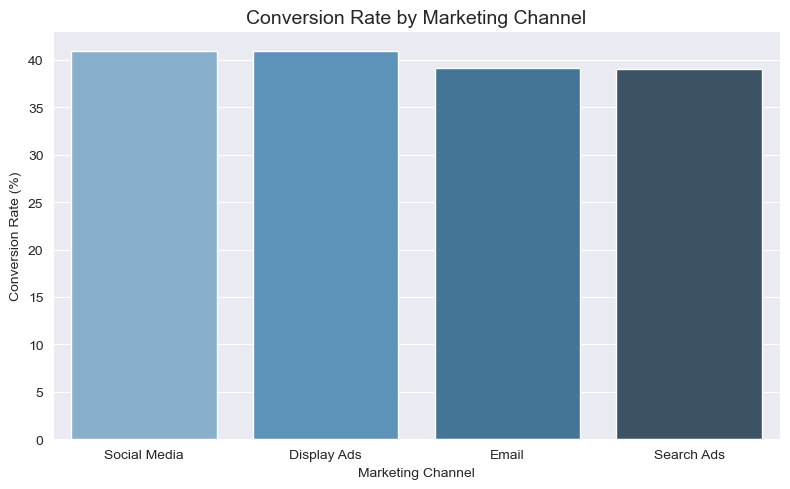

In [26]:
plt.figure(figsize=(8, 5))
sns.barplot(
    data=v1_data, 
    x='Marketing_Channel', 
    y='conversion_rate',
    palette='Blues_d'
)

plt.title('Conversion Rate by Marketing Channel', fontsize=14)
plt.xlabel('Marketing Channel')
plt.ylabel('Conversion Rate (%)')
plt.tight_layout()
plt.show()

### 💡 **V1 Insight — Conversion Rate by Marketing Channel**
- Social Media and Display Ads perform best at ~41%
- Email and Search Ads are slightly lower at ~39%
- Recommendation: Invest more budget in
  Social Media and Display Ads for better conversions!

## V2 — Total Purchases by Region

In [27]:
v2_data = pd.read_sql_query("""
    SELECT 
        Region,
        COUNT(*) AS total_purchases
    FROM campaigns
    WHERE Purchased = 1
    GROUP BY Region
    ORDER BY total_purchases DESC
""", conn)

print(v2_data.to_string(index=False))

Region  total_purchases
 South             1017
  East             1015
  West              982
 North              957


C:\Users\jives\AppData\Local\Temp\ipykernel_9072\4214650159.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


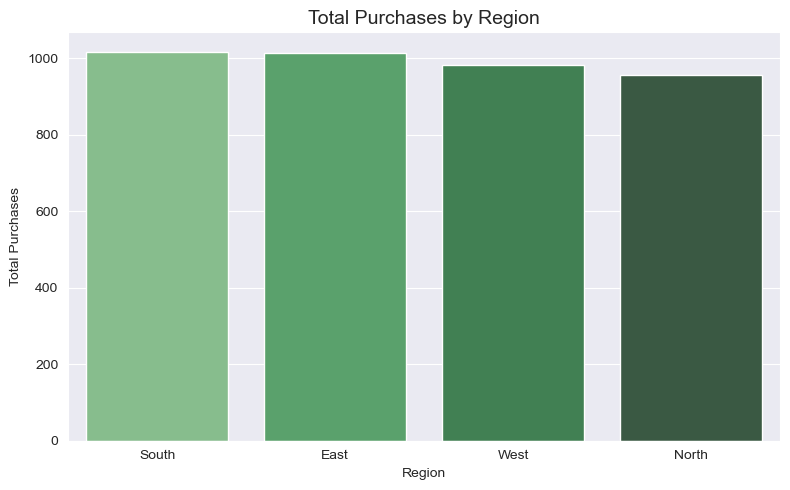

In [28]:
plt.figure(figsize=(8, 5))
sns.barplot(
    data=v2_data,
    x='Region',
    y='total_purchases',
    palette='Greens_d'
)

plt.title('Total Purchases by Region', fontsize=14)
plt.xlabel('Region')
plt.ylabel('Total Purchases')
plt.tight_layout()
plt.show()

### 💡 **V2 Insight — Total Purchases by Region**

- Check your chart for top performing region
- All 4 regions — East, West, North, South
  have been compared by total purchases
- Recommendation: Top performing region should
  get more ad budget and targeted campaigns
  to further boost purchases!

## V3 — Campaign Type Distribution

In [29]:
v3_data = pd.read_sql_query("""
    SELECT 
        Campaign_Type,
        COUNT(*) AS total_customers
    FROM campaigns
    GROUP BY Campaign_Type
""", conn)

print(v3_data.to_string(index=False))

  Campaign_Type  total_customers
Brand Awareness             3290
 Product Launch             3325
 Seasonal Promo             3312


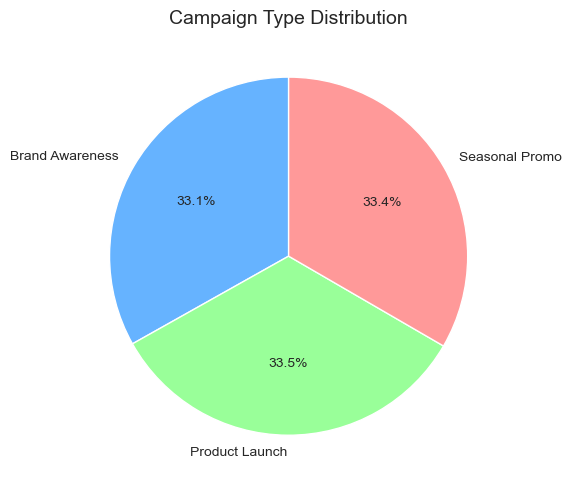

In [30]:
plt.figure(figsize=(8, 5))
plt.pie(
    v3_data['total_customers'],
    labels=v3_data['Campaign_Type'],
    autopct='%1.1f%%',
    colors=['#66b3ff','#99ff99','#ff9999'],
    startangle=90
)

plt.title('Campaign Type Distribution', fontsize=14)
plt.tight_layout()
plt.show()

### 💡 **V3 Insight — Campaign Type Distribution**

- All 3 campaign types are almost equally distributed
- Seasonal Promo → 33.4%
- Product Launch → 33.5%
- Brand Awareness → 33.1%
- Recommendation: Since all campaigns are equal,
  focus on conversion rate rather than distribution
  to find the best performing campaign type!

## V4 — Device Type used by Buyers

In [31]:
v4_data = pd.read_sql_query("""
    SELECT 
        Device_Type,
        COUNT(*) AS total_buyers
    FROM campaigns
    WHERE Purchased = 1
    GROUP BY Device_Type
    ORDER BY total_buyers DESC
""", conn)

print(v4_data.to_string(index=False))

Device_Type  total_buyers
    Desktop          1340
     Tablet          1338
     Mobile          1293


C:\Users\jives\AppData\Local\Temp\ipykernel_9072\857128141.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


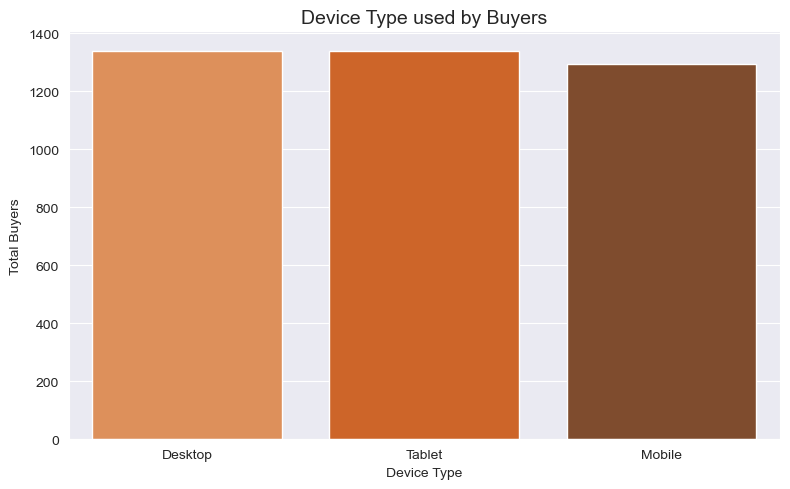

In [32]:
plt.figure(figsize=(8, 5))
sns.barplot(
    data=v4_data,
    x='Device_Type',
    y='total_buyers',
    palette='Oranges_d'
)

plt.title('Device Type used by Buyers', fontsize=14)
plt.xlabel('Device Type')
plt.ylabel('Total Buyers')
plt.tight_layout()
plt.show()

### 💡 **V4 Insight — Device Type used by Buyers**

- Check your chart for top device type
- Desktop, Mobile, Tablet compared by purchases
- Recommendation: Optimize website and ads
  for the most used device type —
  better user experience = more conversions!

## V5 — Region x Channel Heatmap

In [33]:
v5_data = pd.read_sql_query("""
    SELECT 
        Region,
        Marketing_Channel,
        ROUND(AVG(Purchased) * 100, 2) AS conversion_rate
    FROM campaigns
    GROUP BY Region, Marketing_Channel
""", conn)

print(v5_data.to_string(index=False))

Region Marketing_Channel  conversion_rate
  East       Display Ads            39.62
  East             Email            39.37
  East        Search Ads            39.71
  East      Social Media            43.02
 North       Display Ads            41.41
 North             Email            40.10
 North        Search Ads            36.46
 North      Social Media            37.52
 South       Display Ads            41.23
 South             Email            38.63
 South        Search Ads            39.74
 South      Social Media            42.90
  West       Display Ads            41.56
  West             Email            38.36
  West        Search Ads            40.34
  West      Social Media            40.30


In [34]:
v5_pivot = v5_data.pivot(
    index='Region',
    columns='Marketing_Channel',
    values='conversion_rate'
)

print(v5_pivot)

Marketing_Channel  Display Ads  Email  Search Ads  Social Media
Region                                                         
East                     39.62  39.37       39.71         43.02
North                    41.41  40.10       36.46         37.52
South                    41.23  38.63       39.74         42.90
West                     41.56  38.36       40.34         40.30


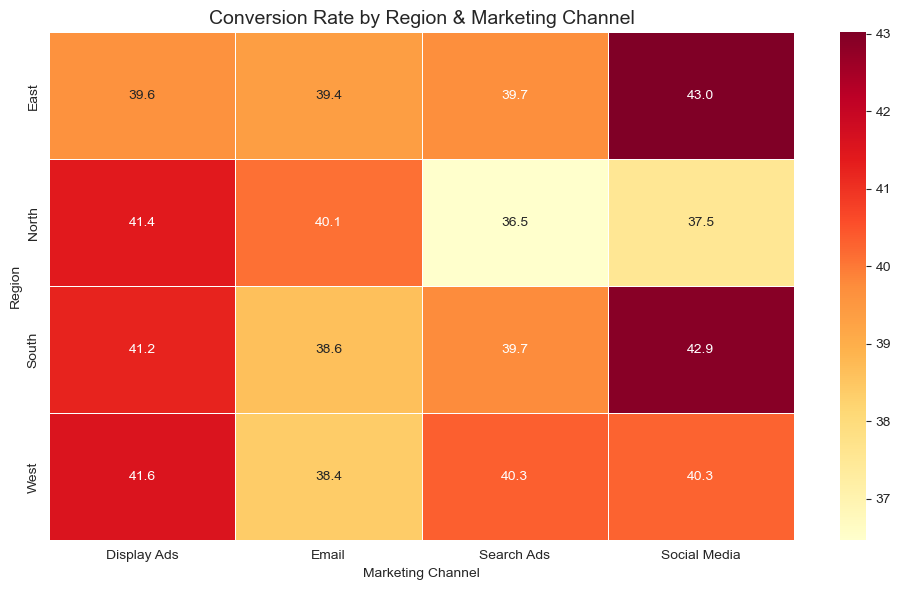

In [35]:
plt.figure(figsize=(10, 6))
sns.heatmap(
    v5_pivot,
    annot=True,
    fmt='.1f',
    cmap='YlOrRd',
    linewidths=0.5
)

plt.title('Conversion Rate by Region & Marketing Channel', fontsize=14)
plt.xlabel('Marketing Channel')
plt.ylabel('Region')
plt.tight_layout()
plt.show()

### 💡 **V5 Insight — Region x Channel Conversion Matrix**

- Heatmap shows which channel works best
  in which region
- Darker color = higher conversion rate
- Recommendation: Use the best performing
  channel for each region specifically —
  dont use same strategy for all regions!
  Example: If Email works best in East,
  focus Email campaigns there!

# 📊 Phase 5 — Key Insights & Findings

---

## 🏆 Top 5 Business Insights

### 1️⃣ Overall Conversion Rate
- Out of 9,929 customers only **40%** purchased
- **5,958** customers did not convert
- **3,973** customers purchased
- Recommendation: Focus on converting the
  remaining 60% customers with better targeting!

### 2️⃣ Best Marketing Channel
- **Social Media** and **Display Ads** perform best at **~41%**
- Email and Search Ads slightly lower at **~39%**
- Recommendation: Invest more budget in
  Social Media and Display Ads for better conversions!

### 3️⃣ Age Group Analysis
- **Young (18-30)** has highest purchase rate of **41.69%**
- **Senior (51+)** close behind at **40.76%**
- **Middle (31-50)** has lowest rate of **38.36%**
- Recommendation: Target Young age group
  with more campaigns for maximum conversions!

### 4️⃣ Discount Impact
- Buyers received avg discount of **12.64%**
- Non Buyers received avg discount of **8.31%**
- Buyers got **4.33% higher discount** than non buyers
- Higher discount clearly drives more purchases!
- Recommendation: Offer 12-15% discount to
  non converting customers to push them to buy!

### 5️⃣ Regional Performance
- **South** leads with **1,017** purchases
- **East** close behind with **1,015** purchases
- **West** has **982** purchases
- **North** has lowest with **957** purchases
- Recommendation: Focus more budget on
  South and East regions for maximum ROI!

---

## 🔑 Overall Recommendation
- Target **Young customers** with **Social Media** campaigns
- Offer **12-15% discount** to non converting customers
- Focus budget on **South and East** regions
- Use **Seasonal Promo** campaigns for best results


---

## 📌 Final Insights
- Social Media and Display Ads show the highest conversion rates
- South and East regions contribute the most to total purchases
- Younger age group (18–30) is the most active segment
- Higher discounts lead to increased purchasing behavior

## 🚀 Business Recommendation
- Focus more budget on Social Media campaigns
- Target young audience for better ROI
- Optimize discount strategies to boost conversions
